# 10 Loading Case Analysis

Classify the held-out test strain histories into simple loading-case groups, then compare per-class test errors for the saved checkpoints.

In [1]:
import os
from pathlib import Path

os.environ['COURSEWORK_DEVICE'] = 'cpu'

ARTIFACT_ROOT = Path('artifacts')
SEED = 20260328


In [2]:
from IPython.display import Image, display

from Coursework3.RNO_1D_Skeleton import build_default_loading_case_model_specs, run_loading_case_analysis

model_specs = build_default_loading_case_model_specs(artifact_root=ARTIFACT_ROOT)
analysis_results = run_loading_case_analysis(
    model_specs=model_specs,
    artifact_root=ARTIFACT_ROOT,
    split_seed=SEED,
)

analysis_results['model_specs_df']


,label,checkpoint_path,color
0,best_gru,/Users/jackhenry/Library/CloudStorage/OneDrive...,#2ca02c
1,paper_h0_no_rate,artifacts/checkpoints/08_paper_rno_h0_no_rate.pt,#1f77b4
2,paper_h0_with_rate,artifacts/checkpoints/08_paper_rno_h0_with_rat...,#d62728


In [3]:
analysis_results['class_counts_df']


,loading_class,loading_class_label,count
0,cyclic_or_reversing,Cyclic / reversing,52
1,mixed_complex,Mixed / complex,4
2,monotonic_fast,Monotonic fast,2
3,monotonic_slow,Monotonic slow,2


In [4]:
analysis_results['grouped_metrics_df']


,model_label,model_color,loading_class,loading_class_label,n_samples,mean_sample_relative_l2,median_sample_relative_l2,mean_sample_rmse,mean_sample_mae,mean_sample_max_abs_error
0,best_gru,#2ca02c,monotonic_slow,Monotonic slow,2,0.000704,0.000704,0.000351,0.000264,0.002476
1,paper_h0_no_rate,#1f77b4,monotonic_slow,Monotonic slow,2,0.280657,0.280657,0.139866,0.117381,0.376348
2,paper_h0_with_rate,#d62728,monotonic_slow,Monotonic slow,2,0.002760,0.002760,0.001375,0.001108,0.006308
3,best_gru,#2ca02c,monotonic_fast,Monotonic fast,2,0.002192,0.002192,0.001051,0.000409,0.014556
4,paper_h0_no_rate,#1f77b4,monotonic_fast,Monotonic fast,2,0.356369,0.356369,0.171678,0.131430,0.633484
5,paper_h0_with_rate,#d62728,monotonic_fast,Monotonic fast,2,0.004957,0.004957,0.002396,0.001635,0.016625
6,best_gru,#2ca02c,cyclic_or_reversing,Cyclic / reversing,52,0.003184,0.002190,0.001010,0.000378,0.016330
7,paper_h0_no_rate,#1f77b4,cyclic_or_reversing,Cyclic / reversing,52,0.806520,0.807999,0.251962,0.207540,0.702795
8,paper_h0_with_rate,#d62728,cyclic_or_reversing,Cyclic / reversing,52,0.011627,0.010603,0.003671,0.002363,0.022609
9,best_gru,#2ca02c,mixed_complex,Mixed / complex,4,0.002574,0.002082,0.001060,0.000398,0.015560


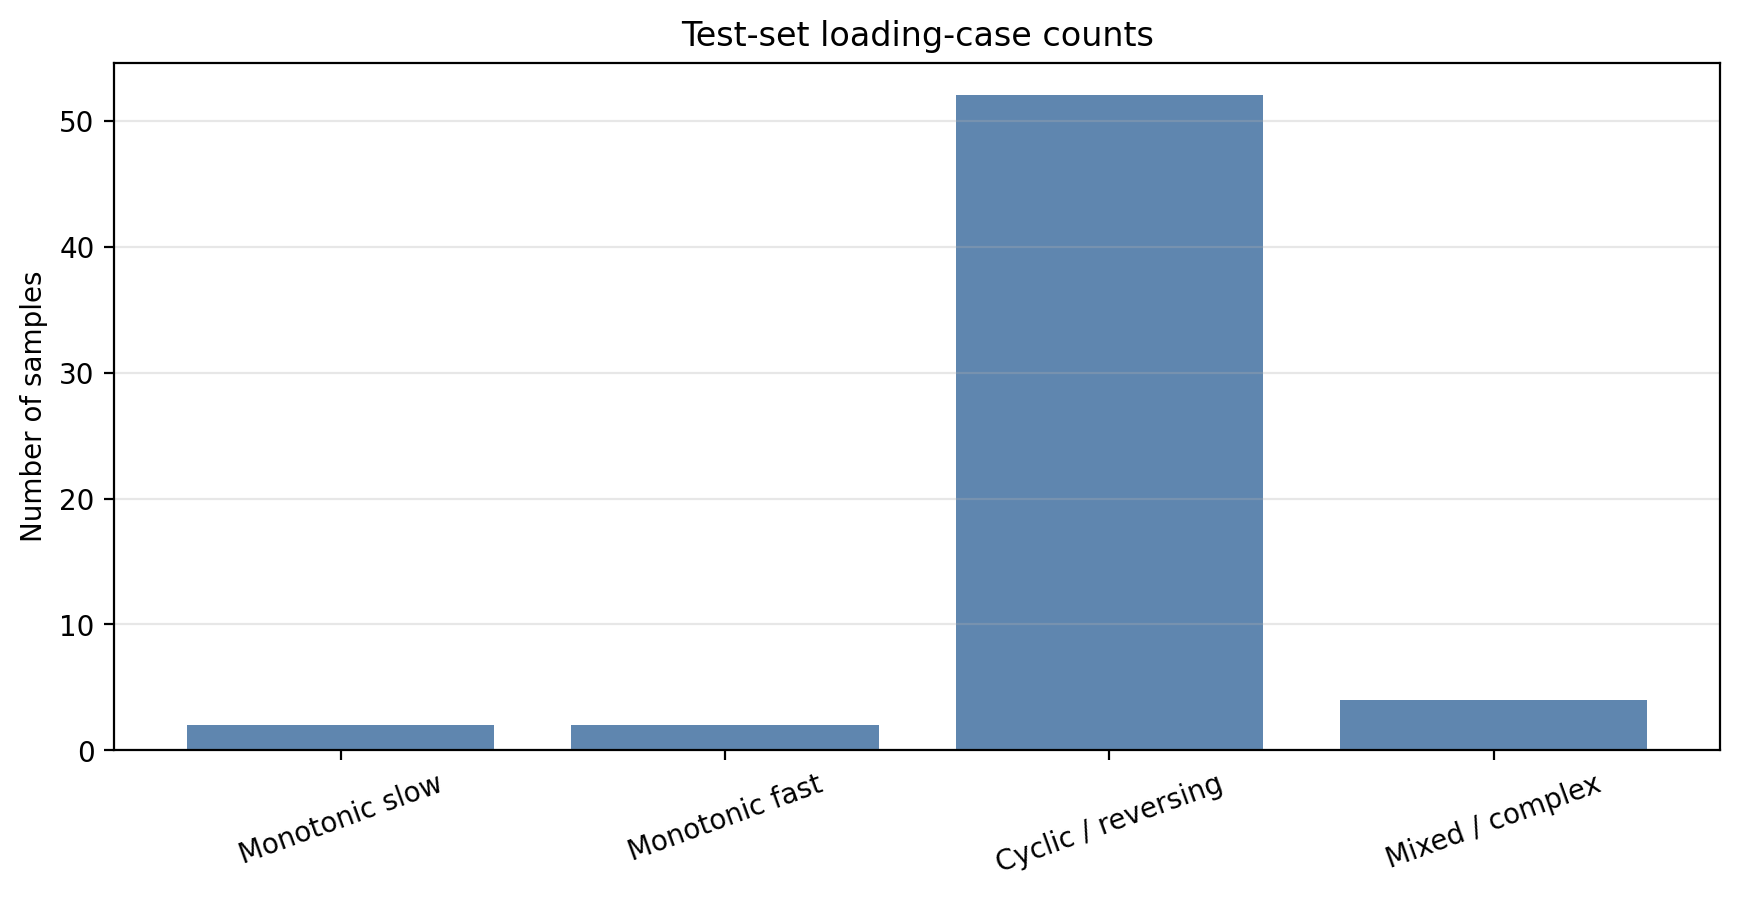

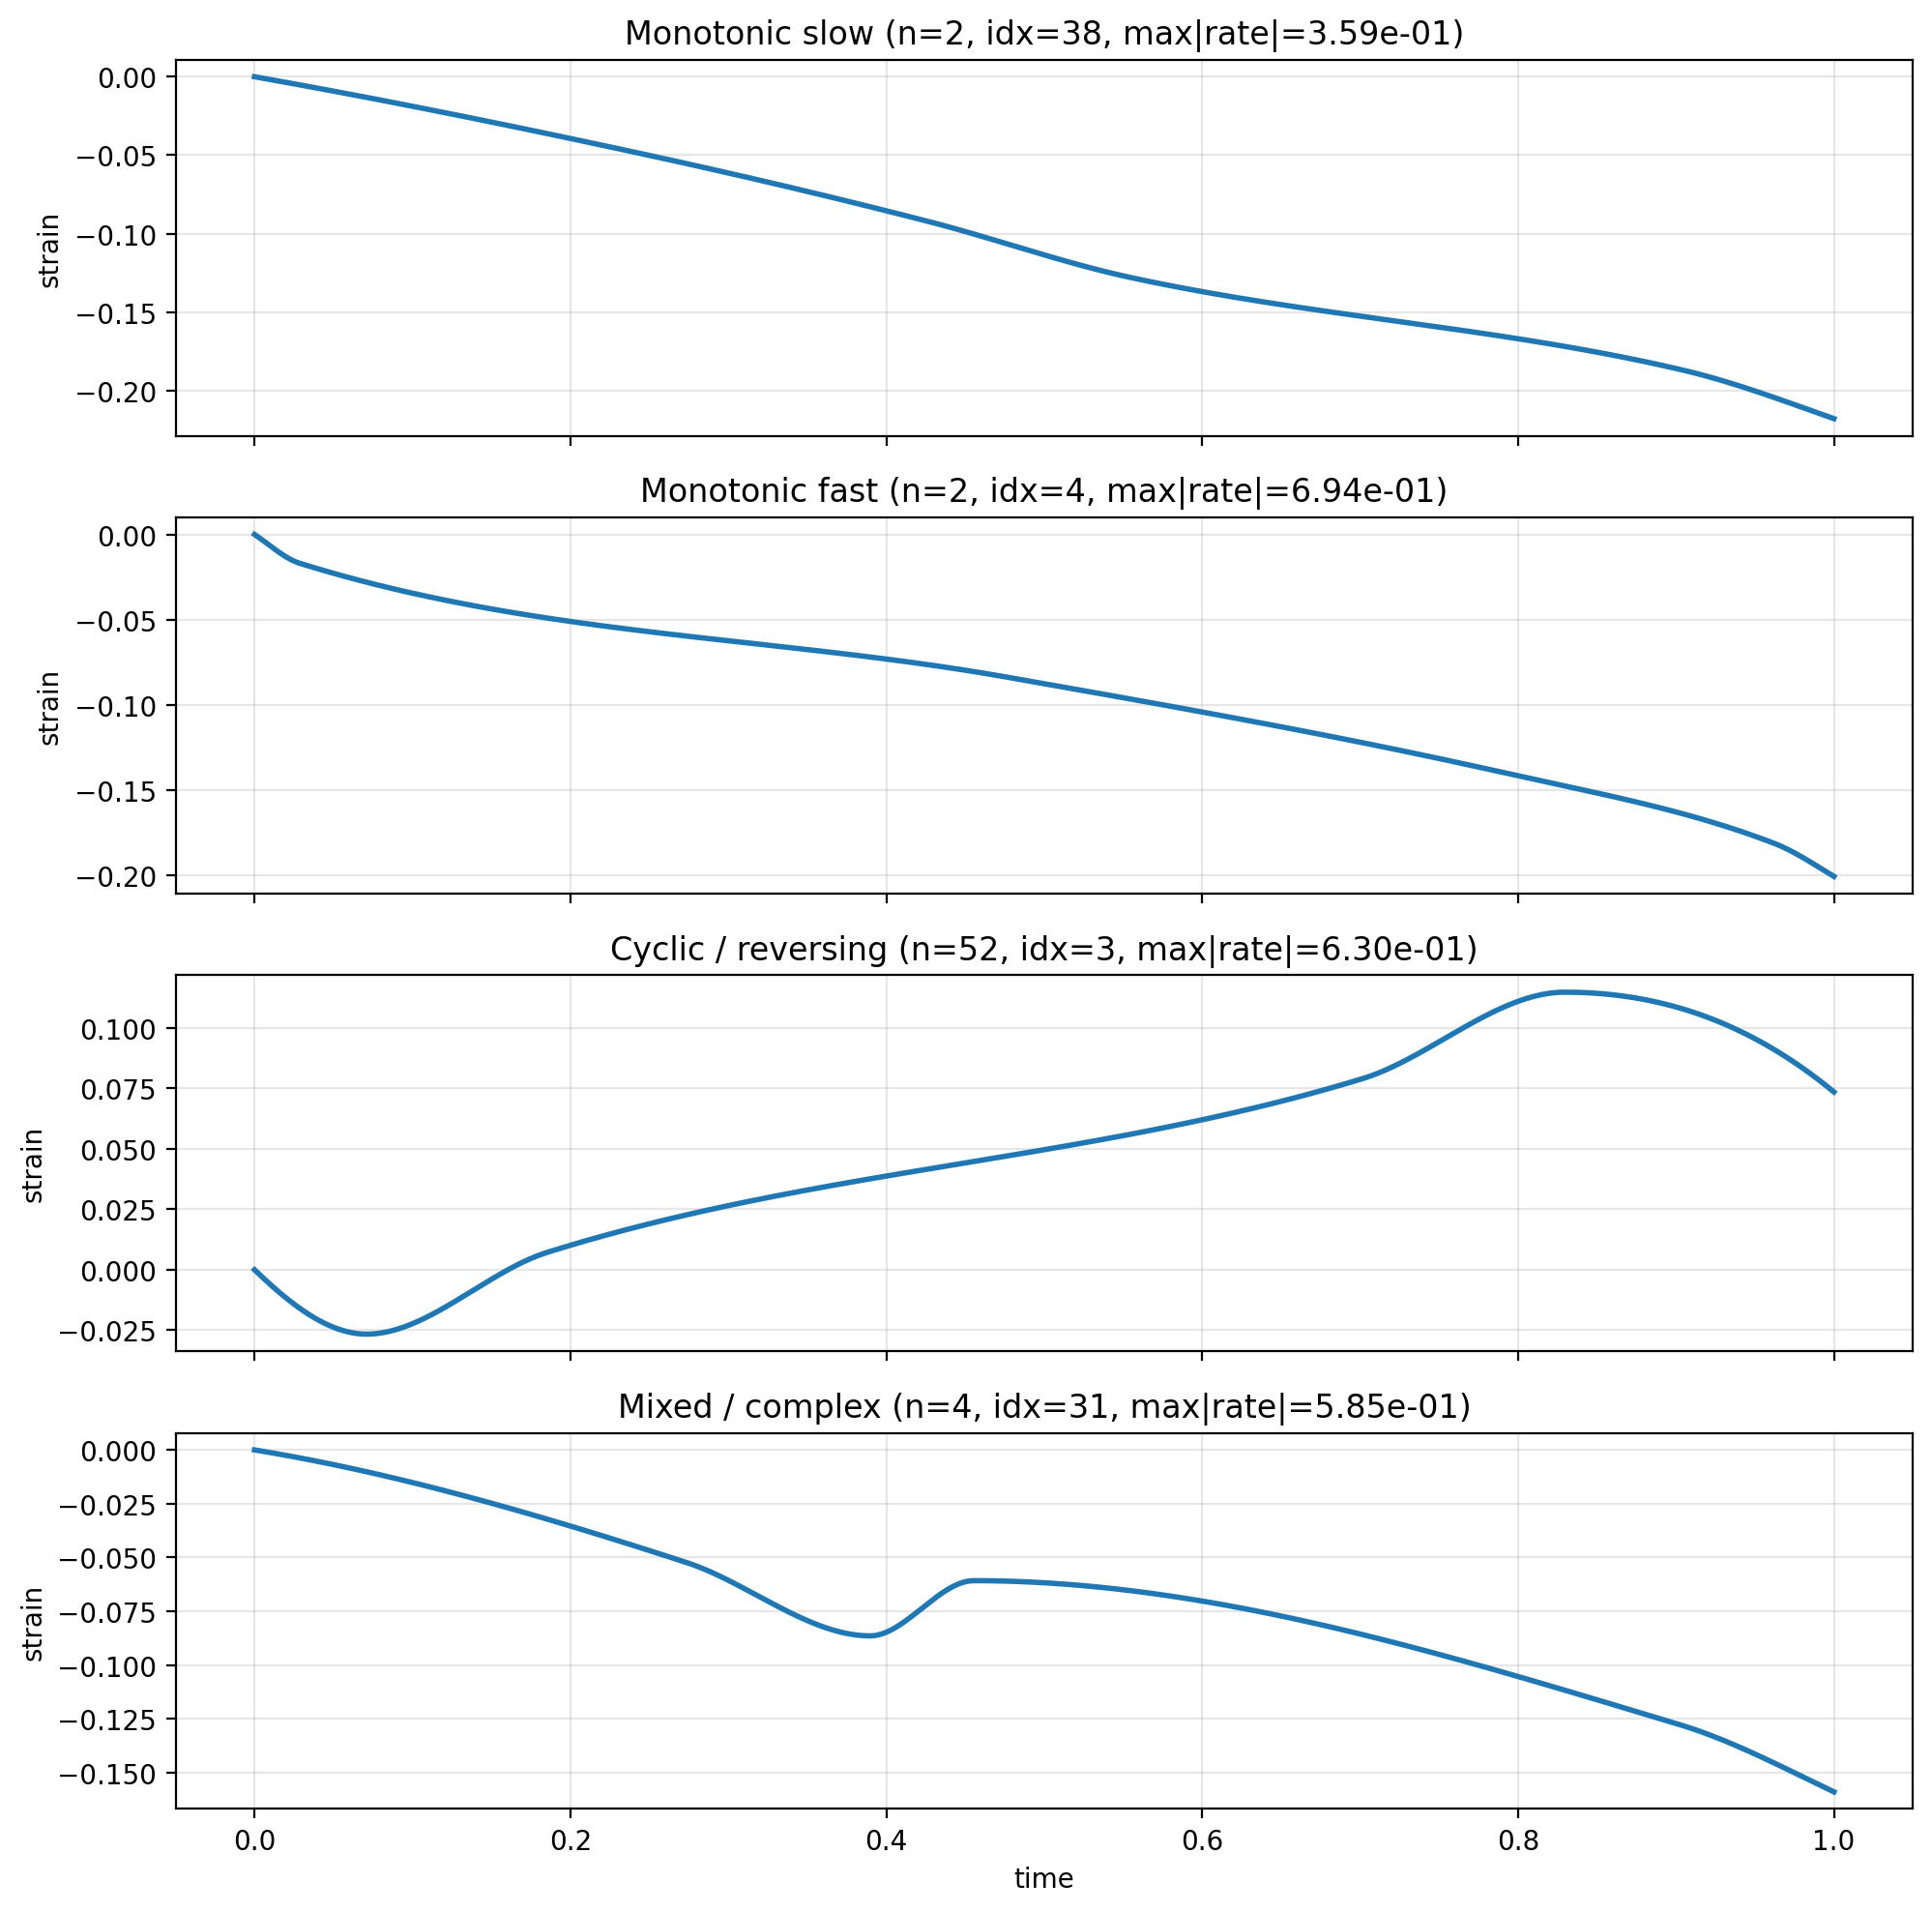

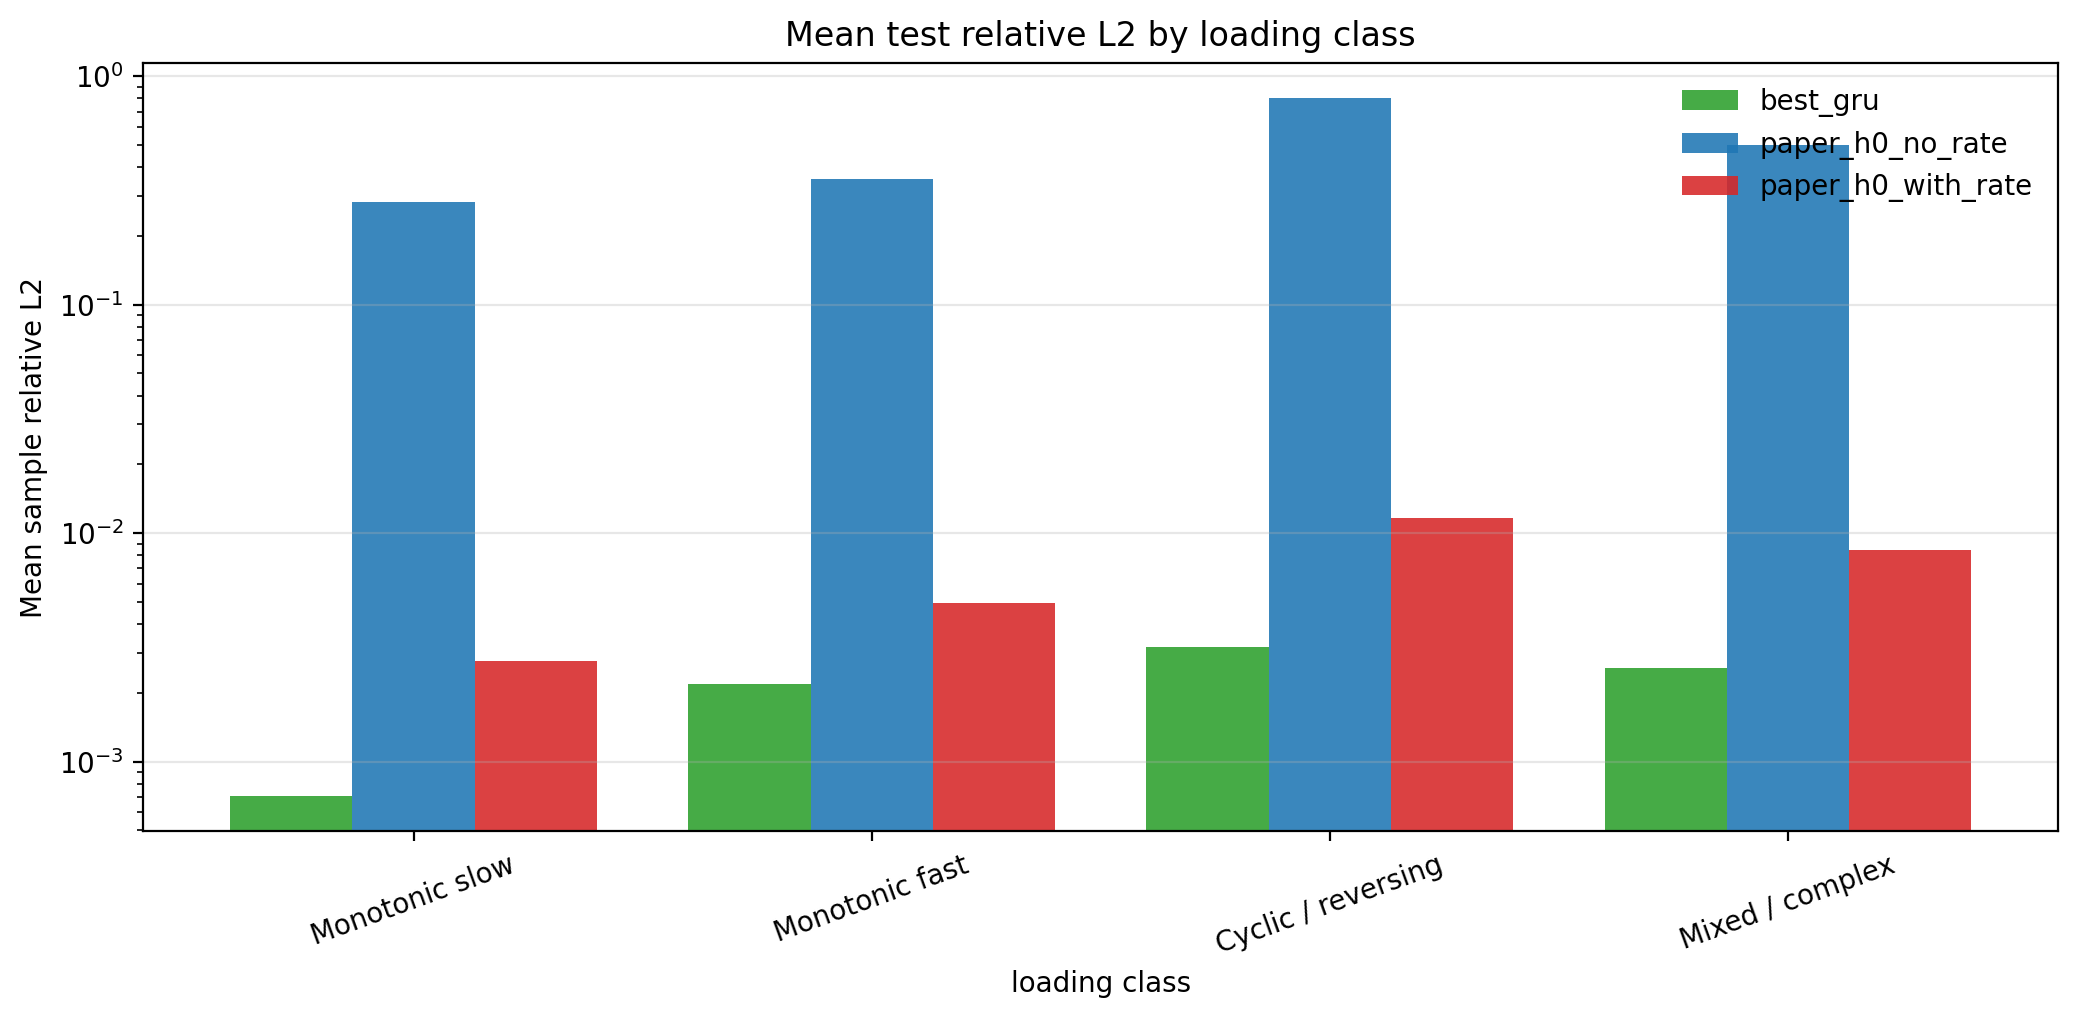

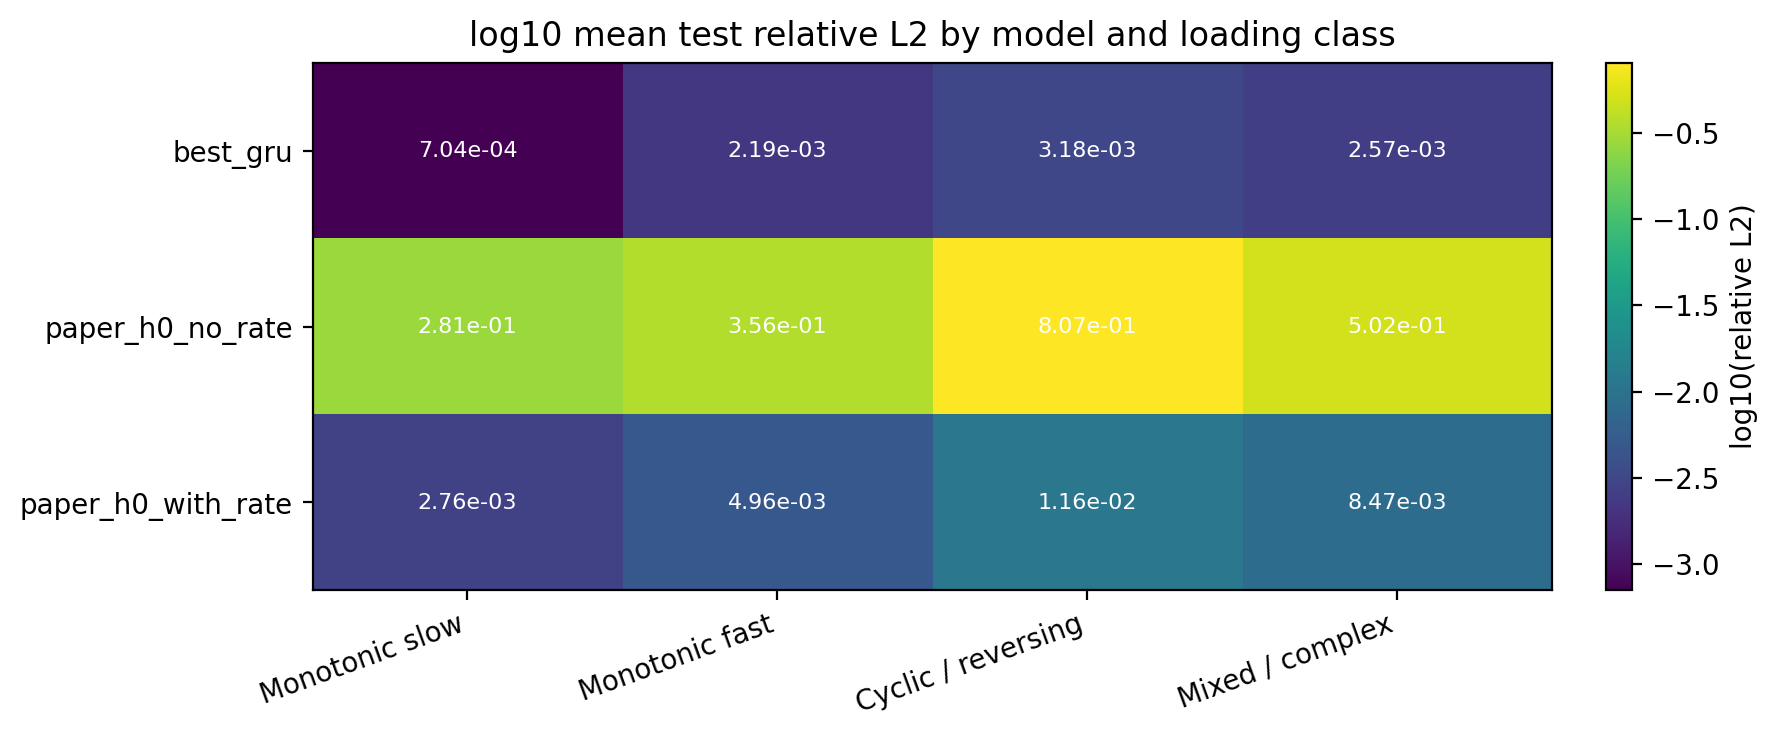

In [5]:
for figure_path in [
    analysis_results['counts_plot_path'],
    analysis_results['representatives_plot_path'],
    analysis_results['relative_l2_plot_path'],
    analysis_results['heatmap_plot_path'],
]:
    display(Image(filename=str(figure_path)))


In [6]:
analysis_results


{'model_specs_df':                 label                                    checkpoint_path  \
 0            best_gru  /Users/jackhenry/Library/CloudStorage/OneDrive...   
 1    paper_h0_no_rate   artifacts/checkpoints/08_paper_rno_h0_no_rate.pt   
 2  paper_h0_with_rate  artifacts/checkpoints/08_paper_rno_h0_with_rat...   
 
      color  
 0  #2ca02c  
 1  #1f77b4  
 2  #d62728  ,
 'class_df':     sample_index  max_abs_rate  mean_abs_rate  turning_points  hold_fraction  \
 0              0      0.563815       0.207803               2          0.085   
 1              1      0.540555       0.208602               2          0.025   
 2              2      0.706226       0.205616               3          0.029   
 3              3      0.630498       0.209374               2          0.009   
 4              4      0.694200       0.200763               0          0.000   
 5              5      0.641078       0.197454               2          0.029   
 6              6      0.674426     